# Naive Bayes Classification

Naive Bayes classification is a fast and simple classification algorithm with only a few tunable parameters. It is very suitable for very high-dimensional datasets. It is often considered as the quick-baseline for a classification problem. There are three kinds of naive Bayes classifiers implemented in scikit-learn:
- GaussianNB (can be applied to any continous data)
-BernoulliNB (can be applied to binary data)
-MultinomialNB (each feature represents an integer count of something)



Let us first describe how a Bayesian classification works and what the intuition behind it is:


## Bayesian Classification

Naive Bayes classifiers are built on Bayesian classification methods. In Bayesian classification, we are interested in finding the probability of a class label given some observed features: $P(L~|~{\rm features})$ using Bayes's rule as follows:

$$
P(L~|~{\rm features}) = \frac{P({\rm features}~|~L)P(L)}{P({\rm features})}
$$

If we are trying to decide between two labels—let's call them $L_1$ and $L_2$—then one way to make this decision is to compute the ratio of the posterior probabilities for each label:

$$
\frac{P(L_1~|~{\rm features})}{P(L_2~|~{\rm features})} = \frac{P({\rm features}~|~L_1)}{P({\rm features}~|~L_2)}\frac{P(L_1)}{P(L_2)}
$$


We need **generative model**: a model that can help us compute $P({\rm features}~|~L_i)$ for each label.



**Naive Bayes**: if we make very naive assumptions about the generative model for each label, we can find a rough approximation of the generative model for each class, and then proceed with the Bayesian classification.


In [3]:
# starndard boiler plate imports
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns; sns.set()

## Gaussian Naive Bayes

Assumption: *data from each label is drawn from a simple Gaussian distribution*.


In [4]:
from sklearn.datasets import make_blobs
X, y = make_blobs(100, 2, centers=2, random_state=2, cluster_std=1.5)
print("shape of X:", X.shape)
print("shape of y:", y.shape)

shape of X: (100, 2)
shape of y: (100,)


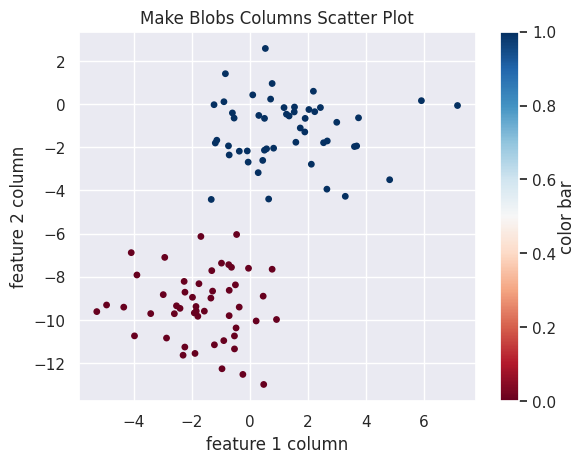

In [5]:
plt.scatter(X[:,0], X[:,1], c=y, s = 15, cmap='RdBu')
plt.title("Make Blobs Columns Scatter Plot")
plt.xlabel("feature 1 column")
plt.ylabel("feature 2 column")
cbar = plt.colorbar()
cbar.set_label("color bar", labelpad=+1)
plt.show()


One extremely fast way to create a simple model is to assume that the data is described by a Gaussian distribution with no covariance between dimensions. This model can be fit by simply finding the mean and standard deviation of the points within each label.


With this generative model in place for each class, we have a simple recipe to compute the likelihood $P({\rm features}~|~L_i)$ for any data point, and thus we can quickly compute the posterior ratio and determine which label is the most probable for a given point. This procedure is implemented in Scikit-Learn's ``sklearn.naive_bayes.GaussianNB`` estimator:

In [ ]:
from sklearn.naive_bayes import GaussianNB # importing learning class
model = GaussianNB() #instantiate the learning class


model.fit(X, y); # use the mode on your data to learn


Now let's generate some new data and predict the label:

In [ ]:
# let us use numpy random number generator
rng = np.random.RandomState(0)

Xnew = [-6, -14] + [14, 18] * rng.rand(2000, 2)

In [ ]:
Xnew

array([[ 1.68338905, -1.12659141],
       [ 2.43868727, -4.19210271],
       [-0.06883281, -2.37390596],
       ...,
       [-4.32134532, -7.70649139],
       [ 0.08823081,  0.94005305],
       [ 7.05928655, -8.44990818]])

In [ ]:
ynew = model.predict(Xnew)

In [ ]:
ynew

array([1, 1, 1, ..., 0, 1, 1])

Now we impose scatter plot this new data on top of our training data to get an idea of where the decision boundary is:

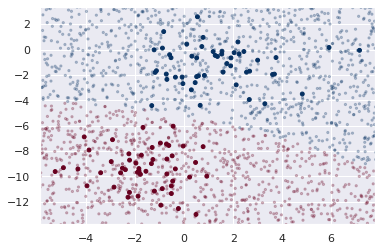

In [ ]:
plt.scatter(X[:, 0], X[:, 1], c=y, s=15, cmap='RdBu') # scatter plot of our training data
lim = plt.axis()
plt.scatter(Xnew[:, 0], Xnew[:, 1], c=ynew, s=5, cmap='RdBu', alpha=0.25) # scatter plot of our new observations
plt.axis(lim);

A nice piece of this Bayesian formalism is that it naturally allows for probabilistic classification, which we can compute using the ``predict_proba`` method:

In [ ]:
yprob = model.predict_proba(Xnew)
yprob[-10:].round(2)
# The columns give the posterior probabilities of the first and second label, respectively.

array([[1.  , 0.  ],
       [1.  , 0.  ],
       [0.89, 0.11],
       [1.  , 0.  ],
       [1.  , 0.  ],
       [1.  , 0.  ],
       [1.  , 0.  ],
       [1.  , 0.  ],
       [0.  , 1.  ],
       [0.15, 0.85]])

An important benefit: Estimates of uncertainty in your classification are part of the outcome.

We must note that the quality of the resulting classification depends on whether the Gaussian asssumption is appropriate for the data. If not, Naive Bayes classification will not produce good results. When the number of features becomes large, the Gaussian assumption is not detrimental enough to prevent Gaussian naive Bayes from being a useful method.

## Multinomial Naive Bayes

Assumption: *features are assumed to be generated from a simple multinomial distribution*.

The multinomial distribution describes the probability of observing counts among a number of categories, and thus multinomial naive Bayes is most appropriate for features that represent counts or count rates. We model the data distribution with a best-fit multinomial distribution.

### Example: Classifying Text

One place where multinomial naive Bayes is often used is in text classification, where the features are related to word counts or frequencies within the documents to be classified. Let use the sparse word count features from the 20 Newsgroups corpus to show how we might classify these short documents into categories. The dataset is called “Twenty Newsgroups”. Here is the official description, quoted from the website: http://qwone.com/~jason/20Newsgroups/. The 20 Newsgroups data set is a collection of approximately 20,000 newsgroup documents, partitioned (nearly) evenly across 20 different newsgroups.  It is a popular data set for experiments in text applications of machine learning techniques, such as text classification and text clustering.

Let us download the data and take a look at the target names:

In [6]:
from sklearn.datasets import fetch_20newsgroups

data = fetch_20newsgroups()
data.target_names

['alt.atheism',
 'comp.graphics',
 'comp.os.ms-windows.misc',
 'comp.sys.ibm.pc.hardware',
 'comp.sys.mac.hardware',
 'comp.windows.x',
 'misc.forsale',
 'rec.autos',
 'rec.motorcycles',
 'rec.sport.baseball',
 'rec.sport.hockey',
 'sci.crypt',
 'sci.electronics',
 'sci.med',
 'sci.space',
 'soc.religion.christian',
 'talk.politics.guns',
 'talk.politics.mideast',
 'talk.politics.misc',
 'talk.religion.misc']

For simplicity here, we will select just a few of these categories, and download the training and testing set:

In [7]:
my_cat = ['talk.religion.misc', 'soc.religion.christian',
              'sci.space', 'comp.graphics']
train = fetch_20newsgroups(subset='train', categories=my_cat)
test = fetch_20newsgroups(subset='test', categories=my_cat)

Here is a representative entry from the data:

In [8]:
print(train.data[2])

From: mccall@mksol.dseg.ti.com (fred j mccall 575-3539)
Subject: Re: nuclear waste
Organization: Texas Instruments Inc
Lines: 34

In <1psg95$ree@access.digex.net> prb@access.digex.com (Pat) writes:

[On the issue of 'burning' nuclear wastes using particle beams...]

>How is it ever going to be an Off- the Shelf Technology if someone doesn't
>do it?  Maybe we should do this as part of the SSF design goals. ;-)

>Gee fred.  After your bitter defense of 20 KHz power as a Basic technology
>for SSF, Id think you would support a minor research program like
>this.

I sometimes wonder if your newsfeed gives you different articles than
everyone else, Pat.  Just a *few* corrections:

1) I never 'defended' 20kHz power, other than as something reasonable
to GO LOOK AT.

2) I have also never opposed a *research project* into feasibility of
the spalling reactor approach to 'cleaning' nuclear waste -- I simply
doubt it could be made to work in the Real World (tm), which ought to
become clear fairly q

In order to use this data for machine learning, we need to convert the content of each string into a vector of numbers. Let us use the TD-IDF vectorizer to do so. Let us also create a pipeline that attaches it to a multinomial naive Bayes classifier:

In [9]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import make_pipeline

# instead of a single model = MultinomialNB(), we build a pipeline.

model = make_pipeline(TfidfVectorizer(), MultinomialNB())

With this pipeline, we can apply the model to the training data, and predict labels for the test data:

In [11]:
model.fit(train.data, train.target) # let the learning happen
labels = model.predict(test.data)

Now that we have predicted the labels for the test data, we can evaluate them to learn about the performance of the estimator.
For example, here is the confusion matrix between the true and predicted labels for the test data:

In [12]:
from sklearn.metrics import accuracy_score
accuracy_score(test.target, labels)

0.8016759776536313

In [14]:
from sklearn.metrics import confusion_matrix
mat = confusion_matrix(test.target, labels) # labels are your predictions, test.target are actuals
mat

array([[344,  13,  32,   0],
       [  6, 364,  24,   0],
       [  1,   5, 392,   0],
       [  4,  12, 187,  48]])

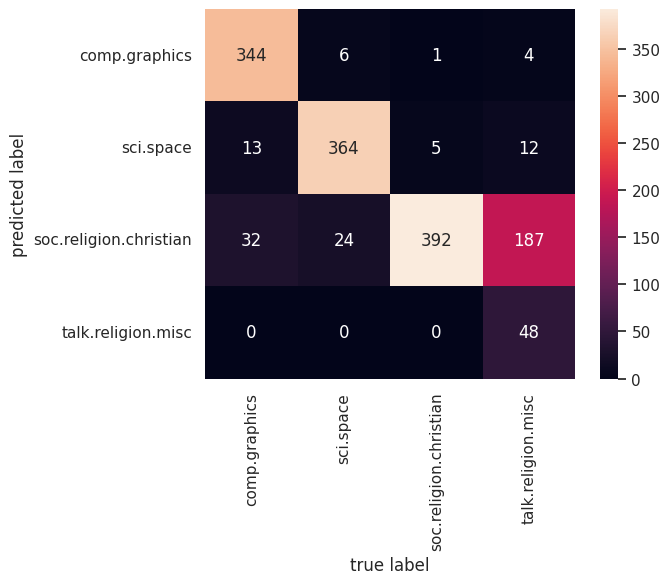

In [15]:
import seaborn as sns
import matplotlib.pyplot as plt

# make sure to import seaborn library
sns.heatmap(mat.T, square=True, annot=True, fmt='d', cbar=True,
            xticklabels=train.target_names, yticklabels=train.target_names)
plt.xlabel('true label')
plt.ylabel('predicted label');


In addition, we have the interesting tool to determine the category for *any* string, using the ``predict()`` method of this pipeline. Let us define a  utility function that will return the prediction for a single string:

In [16]:
def predict_category(s, train=train, model=model):
    pred = model.predict([s])
    return train.target_names[pred[0]]

Let's try it out:

In [17]:
predict_category("AN CARLOS, Calif., Feb. 20, 2024 (GLOBE NEWSWIRE) -- Iovance Biotherapeutics, Inc. (Nasdaq: IOVA) (“Iovance” or “Company”), a biotechnology company focused on innovating, developing, and delivering novel polyclonal tumor infiltrating lymphocyte (“TIL”) therapies for patients with cancer, today announced the pricing of an underwritten offering of 23,014,000 shares of its common stock at an offering price of $9.15 per share. The gross proceeds from the offering, before deducting the underwriting discounts and commissions and other estimated offering expenses payable by Iovance, are expected to be approximately $211 million. The offering is expected to close on or about February 22, 2024, subject to customary closing conditions.")

'sci.space'

In [18]:
predict_category('discussing moon and mars')

'sci.space'

In [19]:
predict_category('determining the screen resolution')

'comp.graphics'

In [20]:
predict_category('school statistics')

'soc.religion.christian'

In [21]:
predict_category("MBA")

'soc.religion.christian'

In [22]:
predict_category("orbit")

'sci.space'

In [23]:
predict_category('Even though it is a simple probability model for the (weighted) frequency of each word in the string, nevertheless, the result is striking. Even a very naive algorithm, when used carefully and trained on a large set of high-dimensional data, can be surprisingly effective in text analysis.')

'sci.space'

In [24]:
predict_category("For example, it models the probability of counts for each side of a k-sided dice rolled n times. For n independent trials each of which leads to a success for exactly one of k categories, with each category having a given fixed success probability, the multinomial distribution gives the probability of any particular combination of numbers of successes for the various categories.")

'soc.religion.christian'

In [25]:
predict_category("Python for Business Analytics")

'comp.graphics'

Even though it is a simple probability model for the (weighted) frequency of each word in the string, nevertheless, the result is striking. Even a very naive algorithm, when used carefully and trained on a large set of high-dimensional data, can be surprisingly effective in text analysis.


## When to Use Naive Bayes

Advantages:

- They are extremely fast for both training and prediction
- They provide straightforward probabilistic prediction
- They are often very easily interpretable
- They have very few (if any) tunable parameters

These advantages mean a naive Bayesian classifier is often a good choice as an initial baseline classification. Naive Bayes classifiers tend to perform especially well in one of the following situations:

- When the naive assumptions actually match the data (very rare in practice)
- For very well-separated categories, when model complexity is less important
- For very high-dimensional data, when model complexity is less important



Simple classifiers like naive Bayes tend to work as well or better than more complicated classifiers as the dimensionality grows: once you have enough data, even a simple model can be very powerful.